# AG-HYPOPT · Trial 05

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Registry holds four trials: trial_01 (obj 0.1907, best), trial_02 (0.2075), trial_03 (0.2472), trial_04 (0.1987). All random warm-up configs. Common pattern: mu_fit stuck near half of mu_true on every experiment (obj dominated by the mu term), and gamma_fit good at high transmission but degrading at Trans05. Trial_04 (strong gamma_anneal 0.707) had the best gamma recovery; trial_03 (near-zero anneal 0.064) the worst. Proposer still in uniform warm-up (4/5 completed), so candidates remain independent uniform draws with no exploitable ranking information. Context only.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_05'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (4/5 trials)
ID |     ei | params
 1 |      - | {"gamma_anneal": 0.6037521928090351, "lr_gamma": 0.846352631789195, "lr_mu": 17.88313902605355, "sigma_ref": 10.716027601762832}
 2 |      - | {"gamma_anneal": 0.04044802678624232, "lr_gamma": 0.5066951046284146, "lr_mu": 15.211830135499966, "sigma_ref": 5.905503878048903}
 3 |      - | {"gamma_anneal": 0.03656828304537604, "lr_gamma": 0.9993408920520572, "lr_mu": 21.309227789699694, "sigma_ref": 9.69020403339648}
 4 |      - | {"gamma_anneal": 0.3262106641688565, "lr_gamma": 0.9793489546074043, "lr_mu": 27.44194020271372, "sigma_ref": 21.88462075217482}
 5 |      - | {"gamma_anneal": 0.2943034982510836, "lr_gamma": 0.5944184149853942, "lr_mu": 21.91723379577665, "sigma_ref": 6.216054259161121}
 6 |      - | {"gamma_anneal": 0.4166970876905426, "lr_gamma": 0.4171612836240812, "lr_mu": 26.991279333373054, "sigma_ref": 6.284288746243821}
 7 |      - | {"gamma_anneal": 0.5093861497660237, "lr_gamma": 0.8960708018620027, "lr_

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Four completed trials (0.1907, 0.2075, 0.2472, 0.1987) and the proposer is still in the uniform warm-up phase (4/5), so there is no exploiter/interpreter model and the candidates carry no ranking signal. This is the last warm-up draw before TPE turns on. With nothing to discriminate between them, I take the first enumerated proposal. I choose candidate 1.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 1               # first candidate (uniform phase, no ranking signal)


chosen: {'gamma_anneal': 0.6037521928090351, 'lr_gamma': 0.846352631789195, 'lr_mu': 17.88313902605355, 'sigma_ref': 10.716027601762832}
Running  1nW Trans05 ... 

μ 9.39 -> 4.80 | γ 8.5 -> 3.41 | NLL 1.29


Running  1nW Trans20 ... 

μ 17.32 -> 8.50 | γ 8.5 -> 9.70 | NLL 3.30


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 45.62 | γ 14.1 -> 13.20 | NLL 2.58


Running 3nW Trans100 ... 

μ 175.71 -> 76.90 | γ 14.1 -> 13.67 | NLL 2.79



Total: 2.4 min


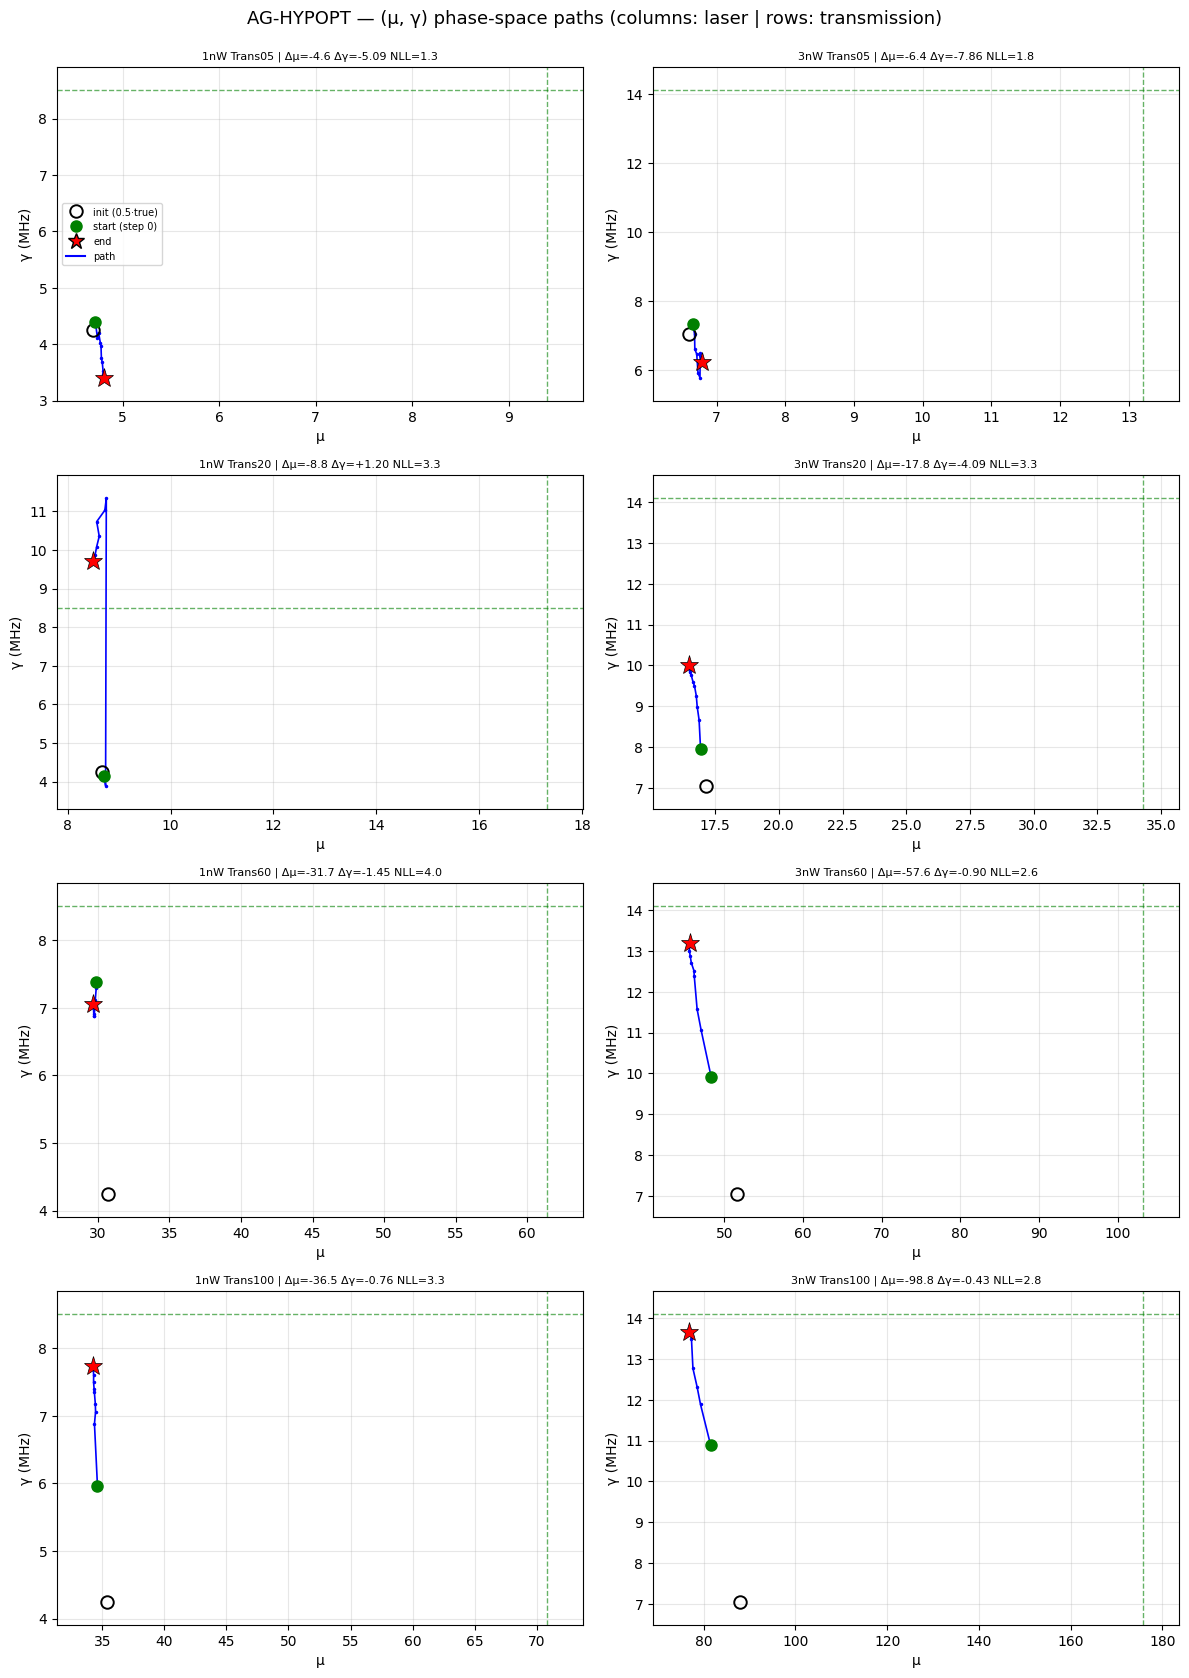

trial finished in 2.4 min
objective = 0.1863 ± 0.0336
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    4.80   -48.9 |     8.50    3.41   -59.9
1nW Trans20    17.32    8.50   -50.9 |     8.50    9.70   +14.1
1nW Trans60    61.37   29.67   -51.6 |     8.50    7.05   -17.0
1nW Trans100   70.82   34.28   -51.6 |     8.50    7.74    -8.9
3nW Trans05    13.20    6.79   -48.6 |    14.10    6.24   -55.8
3nW Trans20    34.28   16.49   -51.9 |    14.10   10.01   -29.0
3nW Trans60   103.20   45.62   -55.8 |    14.10   13.20    -6.4
3nW Trans100  175.71   76.90   -56.2 |    14.10   13.67    -3.1

μ: RMSE 44.547 (rel 52.0%, bias -32.781) | γ: RMSE 3.702 (rel 31.9%, bias -2.424)


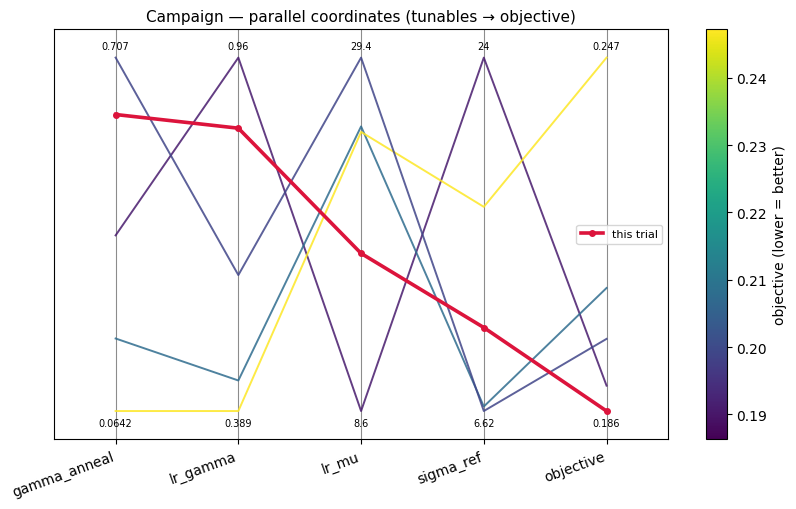

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 05, fifth trial (last of the uniform warm-up); config is an uninformative random draw: sigma_ref 10.72, lr_mu 17.88, lr_gamma 0.846, gamma_anneal 0.604. Result: objective 0.1863 +/- 0.0336 -- the NEW campaign best, narrowly beating trial_01 (0.1907); runtime 2.4 min. mu_fit is again near half of mu_true and quite uniform on 1 nW (Delta-mu% -48.9 to -51.9) but a little lower on 3 nW (-55.8/-56.2), mu RMSE 44.55 (relative 52.0%, bias -32.8). gamma_fit is good at high transmission (3 nW Trans60/100: -6.4/-3.1%; 1 nW Trans100: -8.9%) and even overshoots at 1 nW Trans20 (+14.1%), though Trans05 still degrades (1 nW -59.9%, 3 nW -55.8%); gamma RMSE 3.70 (relative 31.9%). This config sits mid-range on all four knobs (sigma_ref 10.7, lr_mu 17.9, moderate-high lr_gamma 0.85, strong anneal 0.60) and is the best balance observed so far.

**Summary:** Trial 05 (sigma_ref 10.72, lr_mu 17.88, lr_gamma 0.846, gamma_anneal 0.604) -> objective 0.1863 +/- 0.0336, new campaign best (edging trial_01); mu still ~half-truth, gamma strong at high T and even overshoots at 1 nW Trans20.
**Key insight:** A mid-range config (sigma_ref ~11, lr_mu ~18, strong anneal ~0.6) gives the best objective so far, but it only trims the loss slightly -- the uniform ~half-truth mu attractor is still the floor.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
No new structural notes; the real-data attractor note from trial_01 still stands. Warm-up complete -- TPE exploitation begins next trial.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 05 (sigma_ref 10.72, lr_mu 17.88, lr_gamma 0.846, gamma_anneal 0.604): objective 0.1863 +/- 0.0336, new campaign best (edges trial_01); mu still ~half-truth, gamma strong at high T'
KEY_INSIGHT = 'A mid-range config with strong anneal (~0.6) gives the best objective so far but only trims the loss slightly -- the uniform ~half-truth mu attractor remains the floor.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_05 | current best: trial_05


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_06.ipynb. Open it and follow its cells from the top.
